# **Static Word Embedding & Large Word Embedding**
by Jan Eliel Bualoy \
*from [JNV Teaching Notebooks](https://github.com/JNV-Teaching/teaching)* \
\
Instructions: Using your own collected dataset, report the following:

1. Most similar words (Using Static Word Embedding) from the top occurring words (max of 3 words, from Term-Frequency Language Model).

2. PCA of the words from the top 3 words (from the Term-Frequency Language Model).

3. Application of a Hugging Face model to your dataset (BERT-based topic model, BERT-based Sentiment / Emotion model)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install wordcloud scikit-learn seaborn gensim

## Term-Frequency Language Model

In [ ]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [ ]:
corpus = pd.read_excel('cleaned_corpus.xlsx')
corpus.head()

,Unnamed: 0,title,date_published,link,text,tags,source,like_count,reply_parent_id,cleaned_text
0,0,"DPWH seeks lookout order vs officials, contrac...",2025-09-03 12:44:03,https://www.rappler.com/philippines/dpwh-seeks...,"MANILA, Philippines – The Department of Public...","['Budget Watch', 'Bureau of Immigration', 'cor...",rappler,NaN,NaN,manila philippine department public work highw...
1,1,DPWH suspends bidding of locally funded projec...,2025-09-03 11:20:56,https://www.rappler.com/philippines/dpwh-suspe...,"MANILA, Philippines – Newly appointed Public W...","['Budget Watch', 'corruption', 'Corruption in ...",rappler,NaN,NaN,manila philippine newly appoint public work se...
2,2,Kanlaon threat persists as lahar floods drive ...,2025-09-03 10:59:04,https://www.rappler.com/philippines/visayas/ka...,"NEGROS OCCIDENTAL, Philippines – Hundreds of r...","['DENR', 'Disaster Response', 'disaster risk r...",rappler,NaN,NaN,negro occidental philippine hundred resident n...
3,3,DOF: Corruption in flood control projects cost...,2025-09-03 08:36:54,https://www.rappler.com/business/dof-ghost-flo...,"MANILA, Philippines – The Philippine economy m...","['Budget Watch', 'DPWH', 'flood control', 'Phi...",rappler,NaN,NaN,manila philippine philippine economy lose arou...
4,4,House flood projects panel requires members' f...,2025-09-02 17:07:28,https://www.rappler.com/philippines/house-floo...,"MANILA, Philippines – The House mega panel inv...","['DPWH', 'House of Representatives']",rappler,NaN,NaN,manila philippine house mega panel investigate...


In [ ]:
# Top n-grams per document
def top_n_grams(document, top_n=10):
  return document.sort_values(ascending=False).index[:top_n].tolist()

# Wordcloud using BoW and TF-IDF
def plot_wordcloud(data, title):
  wordcloud = WordCloud(
    width=800, height=400, background_color='white'
  ).generate_from_frequencies(data)
  plt.figure(figsize=(10, 6))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.axis('off')
  plt.title(title)
  plt.show()

### Bag of Words (BoW) Language Model

In [ ]:
bow_vectorizer = CountVectorizer(
  # unigram
  # ngram_range=(1, 1),
  # bigram
  ngram_range=(1, 2),
  # trigram
  # ngram_range=(1, 3),
)

doc2vec_bow = bow_vectorizer.fit_transform(corpus['cleaned_text'].dropna().astype(str))
doc2vec_bow = pd.DataFrame(doc2vec_bow.toarray(), columns=bow_vectorizer.get_feature_names_out())
doc2vec_bow.head()

,_____,_corruption,_tuloy,_tuloy aid,aa,aa billion,aa kawlang,aa magnanakaw,aaaaahhh,aabogasya,...,zubiri lawmaker,zubiri one,zulu,zulu senator,zuriaga,zuriaga castor,zy,zy za,ði,ði titino
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
doc2vec_bow.apply(lambda document:
                  top_n_grams(document, top_n=5),
                  axis=1)

,0
0,"[company, contractor, september, bid, dizon]"
1,"[dizon, bid, public, department, september]"
2,"[creek, kanlaon, volcanic, family, alert]"
3,"[budget, department, secretary, house, grow]"
4,"[disclosure, lawmaker, committee, diokno, member]"
...,...
8554,"[etc, look, senator againsts, projetcs becoz, ..."
8555,"[rupt croc, rupt, adiong takot, gresman, pamil..."
8556,"[parin, tropa, balita buwayang, tao, tao inyo]"
8557,"[moro, iimbestiga involve, tama, moro hear, ko..."


wala          636
bayan         551
contractor    522
dtype: int64


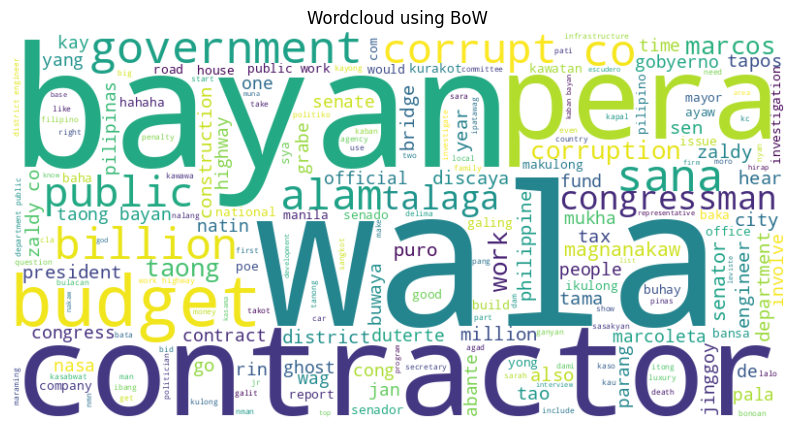

In [ ]:
bow_frequencies = doc2vec_bow.sum(axis=0).sort_values(ascending=False)
print(bow_frequencies.head(3))
plot_wordcloud(bow_frequencies, 'Wordcloud using BoW')

### TF-IDF Language Model

In [ ]:
tfidf_vectorizer = TfidfVectorizer(
  # unigram
  # ngram_range=(1, 1),
  # bigram
  ngram_range=(1, 2),
  # trigram
  # ngram_range=(1, 3),
)

doc2vec_tfidf = tfidf_vectorizer.fit_transform(corpus['cleaned_text'].dropna().astype(str))
doc2vec_tfidf = pd.DataFrame(doc2vec_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
doc2vec_tfidf.head()

,_____,_corruption,_tuloy,_tuloy aid,aa,aa billion,aa kawlang,aa magnanakaw,aaaaahhh,aabogasya,...,zubiri lawmaker,zubiri one,zulu,zulu senator,zuriaga,zuriaga castor,zy,zy za,ði,ði titino
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
doc2vec_tfidf.apply(lambda document:
                    top_n_grams(document, top_n=5),
                    axis=1)

,0
0,"[company, dizon, september, ilbo, several offi..."
1,"[dizon, bid, september, public, appoint]"
2,"[kanlaon, volcanic, creek, tamburong, tamburon..."
3,"[budget, grow, department, secretary, panganda..."
4,"[disclosure, diokno, lawmaker, infra committee..."
...,...
8554,"[etc, look, sit well, prudent sit, becoz confl..."
8555,"[takot expose, pasok insertion, aari pamilya, ..."
8556,"[balita buwayang, inyo najan, najan parin, naj..."
8557,"[moro, lalabas moro, mismong iimbestiga, hear ..."


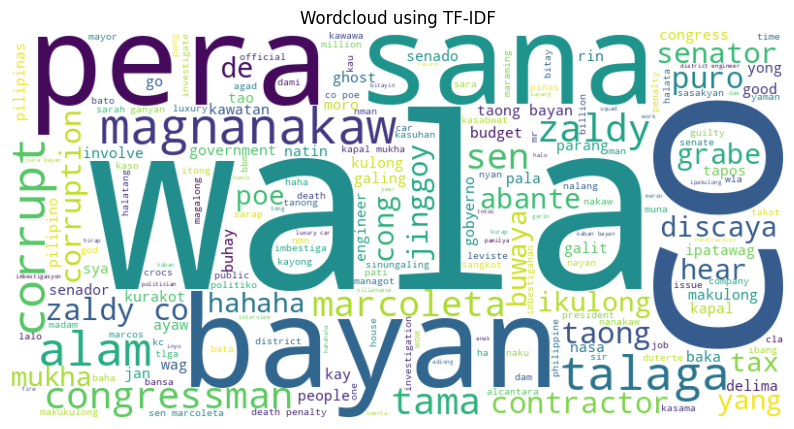

In [ ]:
tfidf_frequencies = doc2vec_tfidf.sum(axis=0).sort_values(ascending=False)
tfidf_frequencies.head(5)
plot_wordcloud(tfidf_frequencies, 'Wordcloud using TF-IDF')

## Static Word Embedding
We will use the Bag of Words Model top 3 words:
- wala
- bayan
- contractor

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import gensim

In [ ]:
# Tokenize the text
corpus['tokenized_text'] = corpus['cleaned_text'].astype(str).apply(lambda x: x.split())

In [ ]:
model = gensim.models.Word2Vec(corpus['tokenized_text'],
                               vector_size=100,  # Dimension of the word vectors
                               min_count=1,    # Ignores all words with total frequency lower min_count
                               sg=0,           # Training algorithm: 0 for CBOW; 1 for Skip-gram
                               window=5,       # Maximum distance between the current & predicted word within a sentence
                               workers=4,      # Number of workers to use for training
                               epochs=10       # Number of iterations over the corpus
                               )

model.save('word2vec.model')

In [ ]:
# Load the model
model = gensim.models.Word2Vec.load('word2vec.model')

# Get vectors from the model
vectors = model.wv

# Number of word vectors generated (columns)
len(vectors)

19296

### 1.) Most Similar Words from Top 3 Words
- 'perang', 0.99
- 'nagnanakaw', 0.99
- 'gahaman', 0.99
- 'nakikinabang', 0.99
- 'mahihirap', 0.99
- 'naawa', 0.99
- 'nanakawin', 0.99
- 'bilyong', 0.98
- 'grabeng', 0.98
- 'pinaghirapan', 0.98



In [ ]:
# The similarity method returns a score of how similar the vectors of two words are. The closer the score is to 1, the higher the similarity. The closer to 0, the lower the similarity.
print("Similarity: ",vectors.similarity('wala', 'bayan'))

# The distance method is the opposite of the similarity method; it returns how dissimilar the vectors of two words are. The closer the score is to 1, the higher the distance and the lower the similarity. The closer to 0, the lower the distance and the higher the similarity.
print("Distance: ",vectors.distance('wala', 'bayan'))

# The most_similar method returns words whose vectors are most similar to the given word.
print("Most similar: ",vectors.most_similar(['wala', 'bayan', 'contractor'], topn=10))

# Output the words whose vectors are most similar and dissimilar to the given words.
print("Similar and Dissimilar: ",vectors.most_similar(
  positive=['wala'],  # most similar to these words and
  negative=['bayan'],  # most dissimilar to these word
  topn=10
))

# Word that is least similar to the other words in the list.
odd_one_out_words = "wala bayan contractor pera budget"
odd_one_out_words = odd_one_out_words.split()
print("Odd one out: ",vectors.doesnt_match(odd_one_out_words))

# Predicting a word given a context of words.
context_words = "wala"
context_words = context_words.split()
print(model.predict_output_word(context_words, topn=5))

Similarity:  0.882593
Distance:  0.11740702390670776
Most similar:  [('perang', 0.9929490685462952), ('nagnanakaw', 0.9917337894439697), ('gahaman', 0.9915585517883301), ('nakikinabang', 0.9912219643592834), ('mahihirap', 0.9909877181053162), ('naawa', 0.9901233315467834), ('nanakawin', 0.9900186657905579), ('bilyong', 0.9899842739105225), ('grabeng', 0.989945650100708), ('pinaghirapan', 0.9898777604103088)]
Similar and Dissimilar:  [('kinukwestyon', 0.5521070957183838), ('itinanong', 0.548491358757019), ('susuho', 0.5312635898590088), ('bonggo', 0.5293558835983276), ('paepal', 0.5069355368614197), ('ggawin', 0.49813103675842285), ('sinabe', 0.4790429472923279), ('inimbitahan', 0.47484278678894043), ('kaalam', 0.47173038125038147), ('bunyag', 0.46750715374946594)]
Odd one out:  budget
[('magnanakaw', 0.009409053), ('puro', 0.007707053), ('taong', 0.0075586042), ('pera', 0.00674632), ('kawawa', 0.0053801257)]


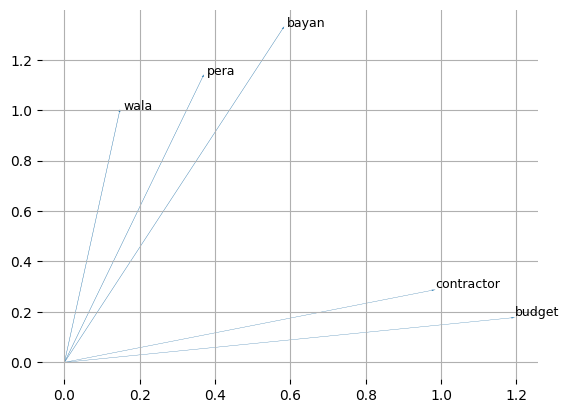

In [ ]:
# Plot word vectors
def plot_vectors(vectors, words):
  # Create a figure and a 2D Axes
  fig, ax = plt.subplots()

  for word in words:
    # Get the vector for the word
    vector = vectors[word]

    # Plot the word near the arrow head
    ax.text(vector[0] + 0.01, vector[1] + 0.01, word, fontsize=9)
    # Plot the vector
    ax.arrow(
      0,                      # Start x
      0,                      # Start y
      vector[0],              # End x
      vector[1],              # End y
      # head_width=0.05,      # Arrow head width
      # head_length=0.1       # Arrow head length
      head_width=0.05 * 0.1,  # Arrow head width
      head_length=0.1 * 0.1,  # Arrow head length
      lw=0.01,                # Arrow line width
      # fc='r',                 # Arrow fill color
      # ec='r'                  # Arrow edge color
    )

  # Remove border around the plot
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  ax.spines['bottom'].set_visible(False)
  ax.spines['left'].set_visible(False)

  plt.grid()

  # Display the plot
  plt.show()


plot_vectors(vectors, ['wala', 'bayan', 'contractor', 'pera', 'budget'])

### Principal Component Analysis (PCA)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [ ]:
# Words most similar to 'wala'
vectors.most_similar('wala', topn=5)
word_set1 = [word for word, score in vectors.most_similar('wala', topn=5)]
print("Similar to 'wala':",word_set1)

# Words most similar to 'bayan'
vectors.most_similar('bayan', topn=5)
word_set2 = [word for word, score in vectors.most_similar('bayan', topn=5)]
print("Similar to 'bayan':",word_set2)

# Words most similar to 'contractor'
vectors.most_similar('contractor', topn=5)
word_set3 = [word for word, score in vectors.most_similar('contractor', topn=5)]
print("Similar to 'contractor':",word_set3)

words_to_viz = word_set1 + word_set2 + word_set3
vecs_to_viz = [vectors[word] for word in words_to_viz]

# Reduce the dimensionality of the vectors to 2D using PCA
pca = PCA(n_components=3)
vecs_PCA = pca.fit_transform(vecs_to_viz)

Similar to 'wala': ['puro', 'talaga', 'pilipinas', 'jan', 'nakakasuhan']
Similar to 'bayan': ['pinapatay', 'maibalik', 'pera', 'makonsensya', 'kidlat']
Similar to 'contractor': ['fifth', 'second', 'locate', 'builder', 'recipient']


In [ ]:
vecs_PCA_df = pd.DataFrame(columns=['word', 'association', 'PC1', 'PC2', 'PC3'])

for idx in range(len(words_to_viz)):
  word = words_to_viz[idx]
  association = 'wala' if word in word_set1 else 'bayan' if word in word_set2 else 'contractor'
  PC1 = vecs_PCA[idx, 0]
  PC2 = vecs_PCA[idx, 1]
  PC3 = vecs_PCA[idx, 2]
  new_row = [word, association, PC1, PC2, PC3]

  vecs_PCA_df.loc[len(vecs_PCA_df)] = new_row

vecs_PCA_df

,word,association,PC1,PC2,PC3
0,puro,wala,4.705387,-0.457527,1.384461
1,talaga,wala,4.636949,-0.424716,1.083201
2,pilipinas,wala,4.326730,0.246912,0.044684
3,jan,wala,4.196340,-0.783322,0.961681
4,nakakasuhan,wala,-2.799573,0.647379,0.329337
5,pinapatay,bayan,-2.923000,0.743217,0.200812
6,maibalik,bayan,-2.450890,0.692059,0.207460
7,pera,bayan,6.875254,1.723851,-2.271661
8,makonsensya,bayan,-3.043439,0.786584,0.265591
9,kidlat,bayan,-2.497193,0.758964,0.272143


### 2.) PCA of Top 3 Words

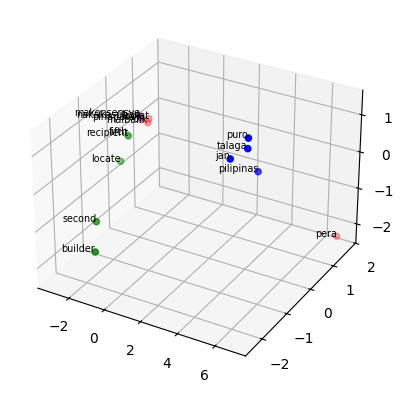

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Map associations to colors
color_mapping = {'wala': 'blue', 'bayan': 'red', 'contractor': 'green'}
colors = [color_mapping[assoc] for assoc in vecs_PCA_df['association']]

ax.scatter(vecs_PCA_df['PC1'], vecs_PCA_df['PC2'], vecs_PCA_df['PC3'], c=colors)

# Add text annotations for each word
for idx in range(len(words_to_viz)):
  ax.text(vecs_PCA_df['PC1'][idx], vecs_PCA_df['PC2'][idx], vecs_PCA_df['PC3'][idx], vecs_PCA_df['word'][idx],
          horizontalalignment='right', size='x-small', color='black', weight='light')

plt.show()

## BERT-based Models

In [ ]:
!pip install transformers

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from transformers import pipeline
from tqdm import tqdm
tqdm.pandas()

### 3.1) Sentiment Analysis

In [ ]:
sentiment_analyzer = pipeline('sentiment-analysis',
                              model='nlptown/bert-base-multilingual-uncased-sentiment',
                              device=0)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


In [ ]:
# keep comments <512 chars
short_comments = corpus[corpus["text"].str.len() < 512].loc[corpus["source"] == "youtube", "text"]

short_comments.head()

,text
150,Invite niyo si magalong at Zaldy Co bat ba aya...
151,Invite niyo si Zaldy Co
152,Kung sino ung important at substantial yung si...
153,Muro muro talaga ang hearing na ito dapat laha...
154,I don’t know why they don’t have lie detectors...


In [ ]:
print(sentiment_analyzer(short_comments.iloc[2])[0])
print(short_comments.iloc[2])

{'label': '5 stars', 'score': 0.33354341983795166}
Kung sino ung important at substantial yung sinasabi, tsaka nagloloko ying microphone 😒


In [ ]:
sentiment_df = short_comments.progress_apply(
    lambda txt: pd.Series(sentiment_analyzer(txt)[0])
)
short_comments = short_comments.to_frame(name="text").join(sentiment_df)
print(short_comments.head())

100%|██████████| 8389/8389 [23:27<00:00,  5.96it/s]

                                                  text    label     score
150  Invite niyo si magalong at Zaldy Co bat ba aya...   1 star  0.386434
151                            Invite niyo si Zaldy Co  3 stars  0.240903
152  Kung sino ung important at substantial yung si...  5 stars  0.333543
153  Muro muro talaga ang hearing na ito dapat laha...  2 stars  0.335490
154  I don’t know why they don’t have lie detectors...  2 stars  0.348501


In [ ]:
short_comments.head()

,text,label,score
150,Invite niyo si magalong at Zaldy Co bat ba aya...,1 star,0.386434
151,Invite niyo si Zaldy Co,3 stars,0.240903
152,Kung sino ung important at substantial yung si...,5 stars,0.333543
153,Muro muro talaga ang hearing na ito dapat laha...,2 stars,0.335490
154,I don’t know why they don’t have lie detectors...,2 stars,0.348501


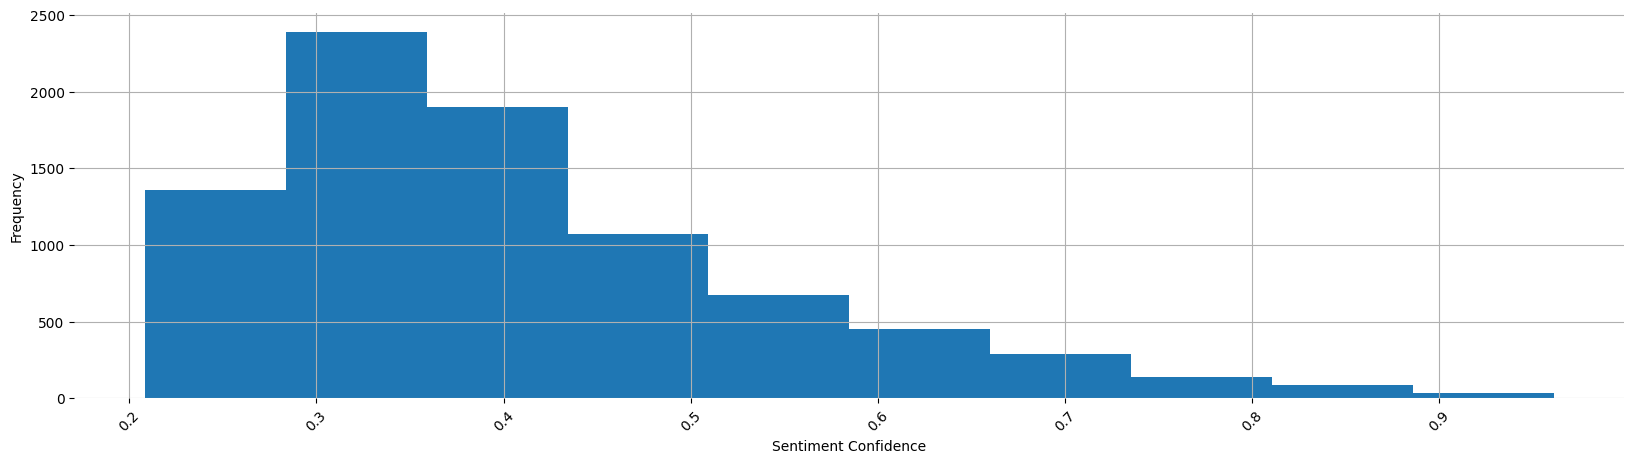

,count
label,
1 star,4839
3 stars,1370
2 stars,1100
5 stars,859
4 stars,221


In [ ]:
fig, ax = plt.subplots(figsize=(20, 5))
short_comments['score'].hist(ax=ax)

# Set labels
ax.set_xlabel('Sentiment Confidence')
ax.set_ylabel('Frequency')

# 45 degree angle for x-axis labels
ax.tick_params(axis='x', rotation=45)

# No spines
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

short_comments['label'].value_counts()

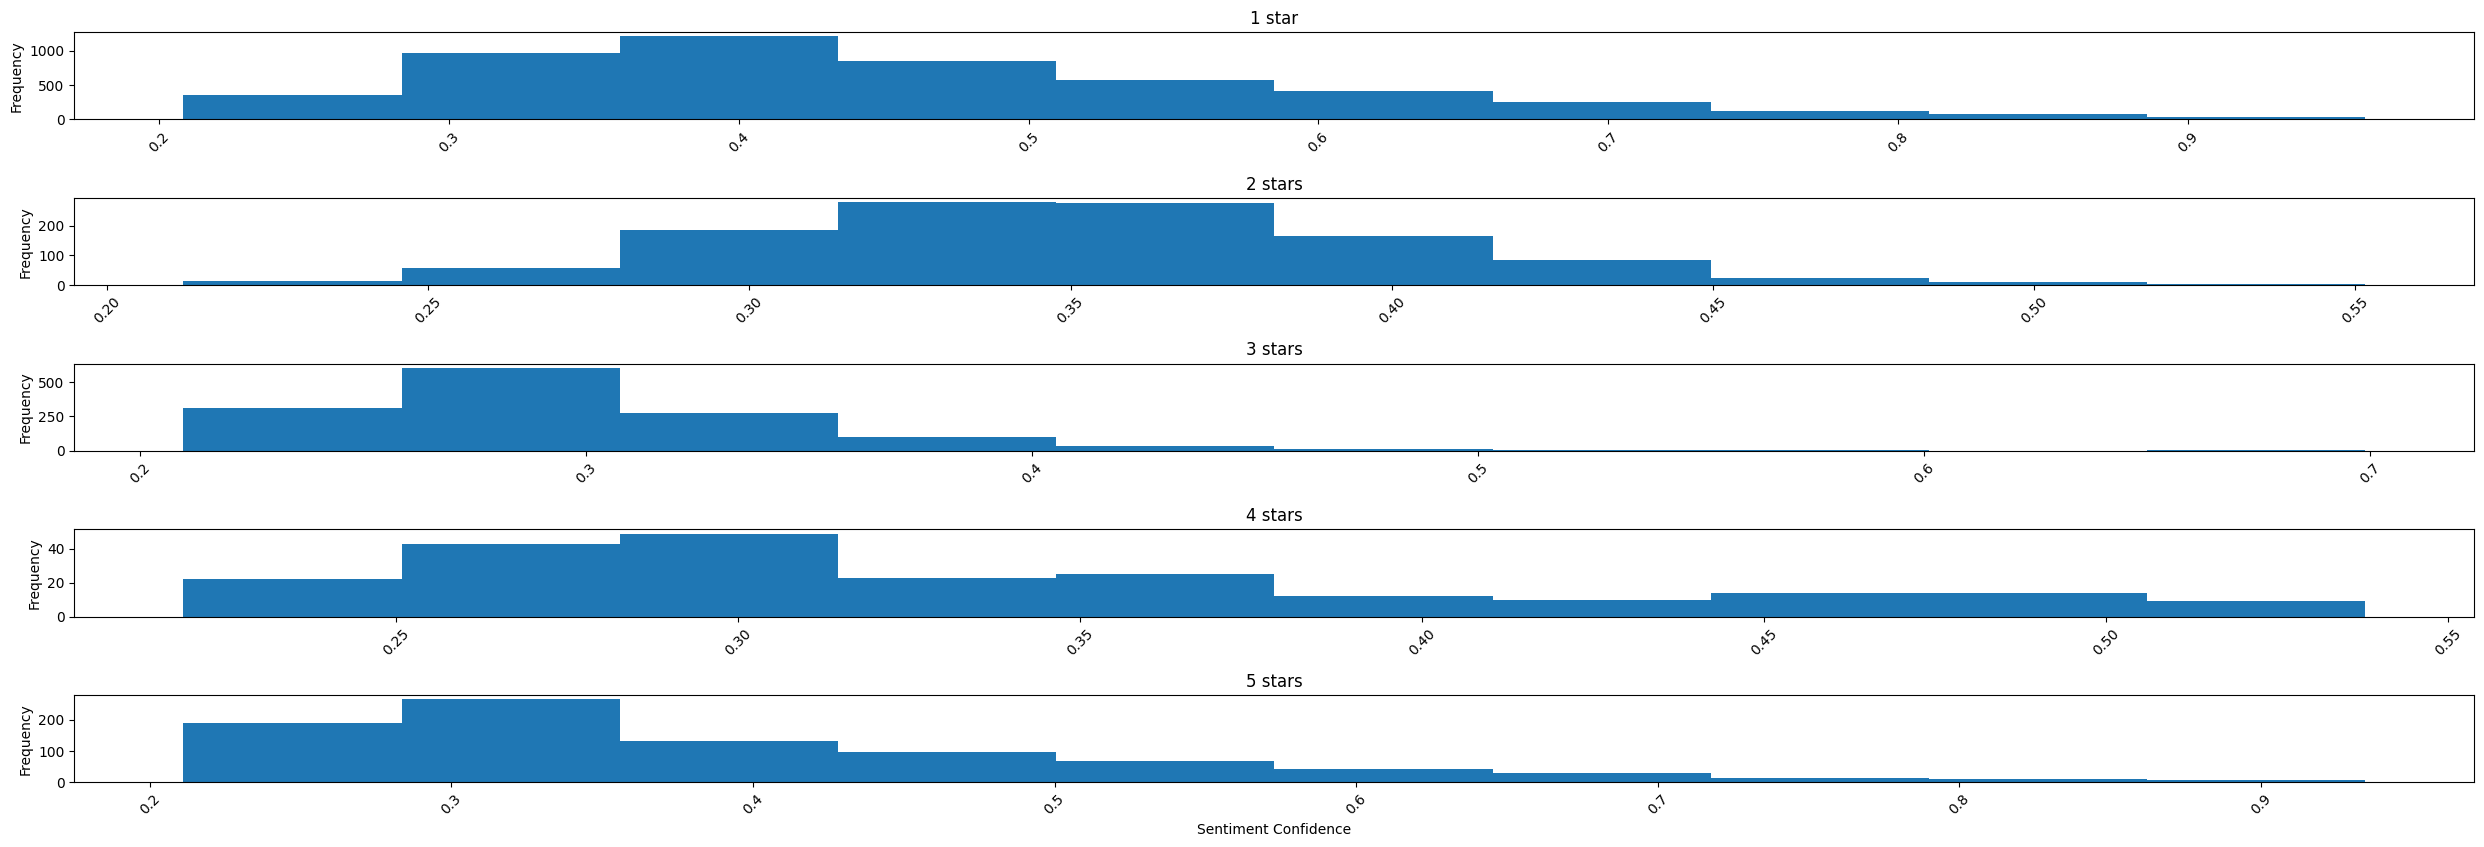

In [ ]:
# Histogram of sentiment confidence along with the sentiment
fig, ax = plt.subplots(5, figsize=(30, 10))

short_comments['score'].hist(
  by=short_comments['label'],
  ax=ax,
)

# Add more space between subplots
plt.subplots_adjust(hspace=0.9)

# Set labels
ax[4].set_xlabel('Sentiment Confidence')
for a in ax:
  a.set_ylabel('Frequency')
  # 45 degree angle for x-axis labels
  a.tick_params(axis='x', rotation=45)

plt.show()

### 3.2) Topic Modelling

In [ ]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 6.2 MB/s eta 0:00:00


In [ ]:
from bertopic import BERTopic

/usr/local/lib/python3.12/dist-packages/hdbscan/plots.py:448: SyntaxWarning: invalid escape sequence '\l'
  axis.set_ylabel('$\lambda$ value')
/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [ ]:
# fill NaN values with empty strings
corpus['cleaned_text'] = corpus['cleaned_text'].fillna('')

In [ ]:
topic_model = BERTopic(language="multilingual",
                       calculate_probabilities=True, verbose=True,
                       n_gram_range=(1, 1), min_topic_size=3
                       )
topics, probs = topic_model.fit_transform(corpus['cleaned_text'])

2025-09-16 15:21:27,992 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/270 [00:00<?, ?it/s]

2025-09-16 15:25:31,010 - BERTopic - Embedding - Completed ✓
2025-09-16 15:25:31,012 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-09-16 15:26:23,087 - BERTopic - Dimensionality - Completed ✓
2025-09-16 15:26:23,088 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-09-16 15:30:00,942 - BERTopic - Cluster - Completed ✓
2025-09-16 15:30:00,955 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-09-16 15:30:01,656 - BERTopic - Representation - Completed ✓


In [ ]:
topic_dataframe = topic_model.get_topic_info()


In [ ]:
try:
  topic_model.visualize_topics()
except ValueError:
  # Dataset too small
  print("Dataset too small to visualize topics")

In [ ]:
topic_model.visualize_distribution(probs[10], min_probability=0.015)

### 3.3) Toxic Comment Classification

In [ ]:
toxic_analyzer = pipeline('text-classification',
                          model='unitary/toxic-bert',
                          device=0)

config.json:   0%|          | 0.00/811 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/174 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


In [ ]:
# keep comments <512 chars
short_comments = corpus[corpus["text"].str.len() < 512].loc[corpus["source"] == "youtube", "text"]


In [ ]:
print(toxic_analyzer(short_comments.iloc[2])[0])
print(short_comments.iloc[2])

{'label': 'toxic', 'score': 0.0032558816019445658}
Kung sino ung important at substantial yung sinasabi, tsaka nagloloko ying microphone 😒


In [ ]:
toxic_df = short_comments.progress_apply(
    lambda txt: pd.Series(toxic_analyzer(txt)[0])
)
short_comments = short_comments.to_frame(name="text").join(toxic_df)
print(short_comments.head())

100%|██████████| 8389/8389 [26:34<00:00,  5.26it/s]

                                                  text  label     score
150  Invite niyo si magalong at Zaldy Co bat ba aya...  toxic  0.021443
151                            Invite niyo si Zaldy Co  toxic  0.007340
152  Kung sino ung important at substantial yung si...  toxic  0.003256
153  Muro muro talaga ang hearing na ito dapat laha...  toxic  0.035558
154  I don’t know why they don’t have lie detectors...  toxic  0.002946


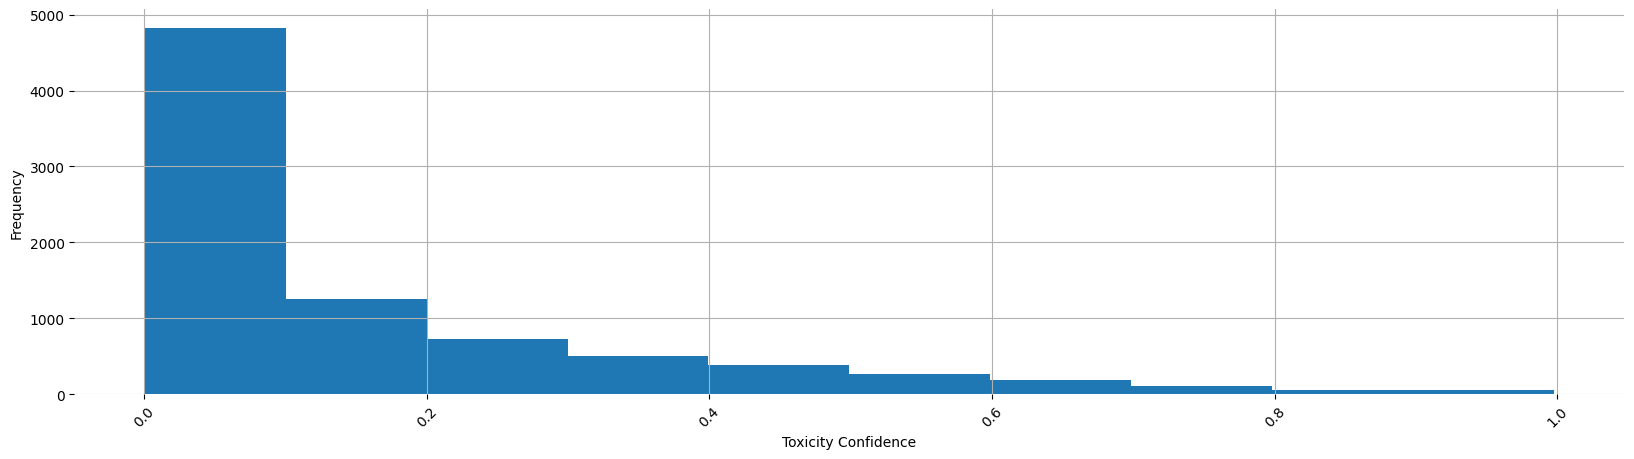

,count
label,
toxic,8389


In [ ]:
fig, ax = plt.subplots(figsize=(20, 5))
short_comments['score'].hist(ax=ax)

# Set labels
ax.set_xlabel('Toxicity Confidence')
ax.set_ylabel('Frequency')

# 45 degree angle for x-axis labels
ax.tick_params(axis='x', rotation=45)

# No spines
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

short_comments['label'].value_counts()